# Trabajo 2 Marketing — Grupo 25
## Mercado 1: E-commerce global (Segmentación, mercados meta y posicionamiento)

**Cliente:** empresa que desea ingresar al mercado y captar segmentos receptivos a **promociones**, considerando la **categoría de producto**.

**Fuentes:** `customers.csv`, `orders.csv`

> **Nota del curso:** Los nombres de los segmentos deben ser definidos por el grupo a partir de las tablas de perfil (no usar IA generativa para caracterizar/nombrar segmentos). En este notebook los clusters se etiquetan como `Segmento 0`, `Segmento 1`, etc.


## 1. Contexto del mercado

El e-commerce global registra transacciones multicanal (web, app, pagos diversos) con fuerte heterogeneidad en gasto, frecuencia y uso de descuentos. La empresa entrante puede priorizar clientes con alta sensibilidad promocional y alineación por categoría preferida, sin descuidar segmentos de alto valor (RFM).


## 2. Librerías

Si `stepmix` no está instalado, ejecutar en terminal: `pip install -r requirements.txt`


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from stepmix.stepmix import StepMix
from stepmix.utils import get_mixed_descriptor

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 3. Carga de datos


In [20]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")

print("Clientes:", customers.shape)
print("Órdenes:", orders.shape)
customers.head()


Clientes: (8000, 20)
Órdenes: (25000, 28)


,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


## 4. Exploración y descripción básica


In [21]:
display(customers.describe().T.round(2))
display(customers.select_dtypes(include="object").describe().T)


,count,mean,std,min,25%,50%,75%,max
age,8000.0,35.62,11.17,18.00,27.00,35.00,43.00,75.00
total_orders,8000.0,16.55,14.68,1.00,5.00,12.00,23.00,79.00
total_spend_usd,8000.0,1558.64,2284.09,4.89,336.06,845.70,1892.16,61282.48
avg_order_value_usd,8000.0,94.85,78.99,5.00,44.69,72.27,118.56,1051.73
days_since_last_purchase,8000.0,59.58,60.61,0.00,16.00,41.00,84.00,582.00
reviews_given,8000.0,3.23,3.94,0.00,0.00,2.00,5.00,28.00
avg_review_score,8000.0,4.11,0.52,1.80,3.80,4.20,4.50,5.00
returns_made,8000.0,0.85,1.41,0.00,0.00,0.00,1.00,11.00
wishlist_items,8000.0,4.46,4.85,0.00,1.00,3.00,6.00,41.00
newsletter_subscribed,8000.0,0.62,0.49,0.00,0.00,1.00,1.00,1.00


,count,unique,top,freq
customer_id,8000,8000,C07984,1
country,8000,20,United States,2509
gender,8000,3,Female,3895
membership_tier,8000,4,Free,4443
registration_date,8000,1862,2026-02-18,26
preferred_category,8000,14,Electronics,1505
preferred_device,8000,3,Mobile,4351
preferred_payment_method,8000,7,Credit Card,3049
acquisition_channel,8000,6,Organic Search,2194


In [22]:
print("Valores nulos — clientes")
display(customers.isnull().sum().sort_values(ascending=False))

print("Valores nulos — órdenes (top)")
display(orders.isnull().sum().sort_values(ascending=False).head(10))

print("IDs duplicados:", customers.customer_id.duplicated().sum(), orders.order_id.duplicated().sum())
print("Clientes en órdenes:", customers.customer_id.isin(orders.customer_id).mean().round(3))


Valores nulos — clientes


customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

Valores nulos — órdenes (top)


customer_rating    15749
order_id               0
order_date             0
customer_id            0
month                  0
quarter                0
day_of_week            0
product_name           0
category               0
unit_price_usd         0
dtype: int64

IDs duplicados: 0 0
Clientes en órdenes: 0.958


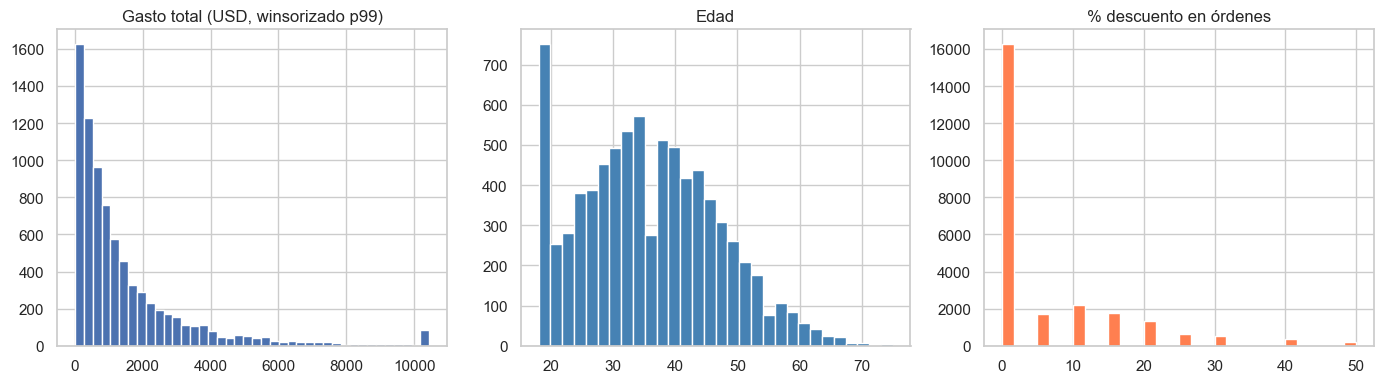

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
customers["total_spend_usd"].clip(upper=customers["total_spend_usd"].quantile(0.99)).hist(ax=axes[0], bins=40)
axes[0].set_title("Gasto total (USD, winsorizado p99)")

customers["age"].hist(ax=axes[1], bins=30, color="steelblue")
axes[1].set_title("Edad")

orders["discount_pct"].hist(ax=axes[2], bins=30, color="coral")
axes[2].set_title("% descuento en órdenes")
plt.tight_layout()
plt.show()


## 5. Limpieza y creación de variables

Ajustes realizados:
- Conversión de fechas y variables binarias explícitas.
- Construcción de **RFM** a nivel cliente desde `orders.csv`.
- Variables de **receptividad promocional** (% órdenes con descuento, descuento promedio).
- Agrupación de categorías/países poco frecuentes en `Other` para modelos categóricos.


In [24]:
orders = orders.copy()
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders["delivery_date"] = pd.to_datetime(orders["delivery_date"], errors="coerce")

customers = customers.copy()
customers["registration_date"] = pd.to_datetime(customers["registration_date"], errors="coerce")
customers["tenure_days"] = (orders["order_date"].max() - customers["registration_date"]).dt.days

# Binarias
customers["is_female"] = (customers["gender"] == "Female").astype(int)
customers["newsletter"] = customers["newsletter_subscribed"].astype(int)
customers["churn_flag"] = customers["churned"].astype(int)

# RFM desde transacciones
ref_date = orders["order_date"].max()
rfm = (
    orders.groupby("customer_id")
    .agg(
        frequency=("order_id", "nunique"),
        monetary=("total_amount_usd", "sum"),
        last_order=("order_date", "max"),
    )
    .reset_index()
)
rfm["recency_days"] = (ref_date - rfm["last_order"]).dt.days

promo = (
    orders.groupby("customer_id")
    .agg(
        promo_order_rate=("discount_pct", lambda s: (s > 0).mean()),
        avg_discount_pct=("discount_pct", "mean"),
        avg_rating=("customer_rating", "mean"),
    )
    .reset_index()
)

df = customers.merge(rfm, on="customer_id", how="left").merge(promo, on="customer_id", how="left")

# Imputación conservadora para clientes sin órdenes en el extracto
df["recency_days"] = df["recency_days"].fillna(df["days_since_last_purchase"])
df["frequency"] = df["frequency"].fillna(df["total_orders"])
df["monetary"] = df["monetary"].fillna(df["total_spend_usd"])
df["promo_order_rate"] = df["promo_order_rate"].fillna(0)
df["avg_discount_pct"] = df["avg_discount_pct"].fillna(0)

# Índices para StepMix (categóricas)
def group_top(s, n=8):
    top = s.value_counts().head(n).index
    return s.where(s.isin(top), "Other")

for col in ["country", "preferred_category", "acquisition_channel"]:
    df[col + "_grp"] = group_top(df[col])
    df[col + "_idx"] = df[col + "_grp"].astype("category").cat.codes

membership_map = {"Free": 0, "Silver": 1, "Gold": 2, "Platinum": 3}
df["membership_idx"] = df["membership_tier"].map(membership_map)

print("Base analítica:", df.shape)
df[["recency_days", "frequency", "monetary", "promo_order_rate"]].describe().round(2)


Base analítica: (8000, 38)


,recency_days,frequency,monetary,promo_order_rate
count,8000.00,8000.00,8000.00,8000.00
mean,598.30,3.78,449.60,0.34
std,532.87,4.10,541.75,0.31
min,0.00,1.00,8.61,0.00
25%,168.00,2.00,172.69,0.00
50%,439.00,3.00,330.20,0.33
75%,889.00,4.00,569.46,0.50
max,2280.00,64.00,15536.43,1.00


## 6. Segmentación socio-demográfica / conductual

**Variables seleccionadas (justificación breve):**
- *Gaussianas:* edad, gasto total, reseñas — perfil de valor y engagement.
- *Binarias:* género (mujer), newsletter, churn — comportamiento y retención.
- *Categóricas:* membresía, categoría preferida, canal de adquisición — heterogeneidad estructural.

**Métodos:** K-Means (distancia euclídea, datos estandarizados) y StepMix (LCA con mezcla de distribuciones).


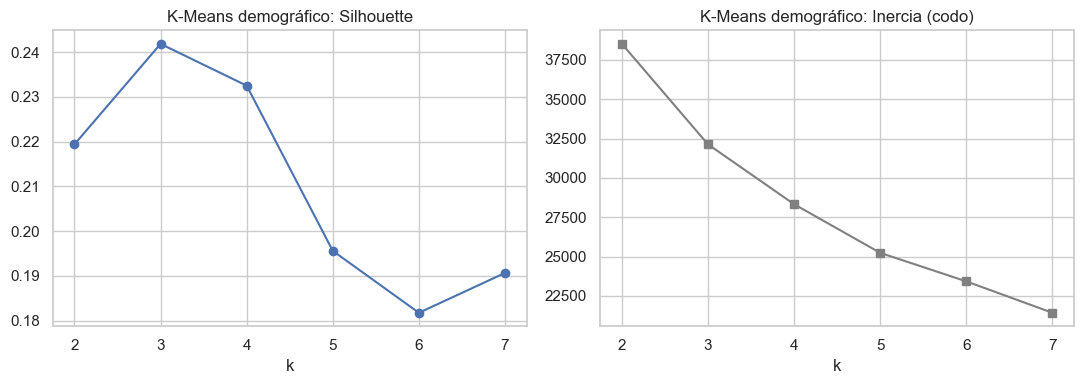

,k,silhouette,inertia
0,2,0.219377,38512.822055
1,3,0.241839,32129.341414
2,4,0.232495,28327.618067
3,5,0.195567,25238.244933
4,6,0.181726,23427.931262
5,7,0.190640,21431.891352


In [25]:
demo_num = ["age", "total_spend_usd", "reviews_given", "wishlist_items", "promo_order_rate", "avg_discount_pct"]
X_demo = StandardScaler().fit_transform(df[demo_num])

K_range = range(2, 8)
sil_demo, inertias = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_demo)
    sil_demo.append(silhouette_score(X_demo, km.labels_))
    inertias.append(km.inertia_)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(K_range), sil_demo, marker="o")
ax[0].set_title("K-Means demográfico: Silhouette")
ax[0].set_xlabel("k")

ax[1].plot(list(K_range), inertias, marker="s", color="gray")
ax[1].set_title("K-Means demográfico: Inercia (codo)")
ax[1].set_xlabel("k")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(K_range), "silhouette": sil_demo, "inertia": inertias})


In [26]:
mixed_data, mixed_descriptor = get_mixed_descriptor(
    dataframe=df,
    binary=["is_female", "newsletter", "churn_flag"],
    categorical=["membership_idx", "preferred_category_idx", "acquisition_channel_idx"],
    gaussian=["age", "total_spend_usd", "reviews_given"],
)

bic_demo, aic_demo = [], []
for k in range(2, 7):
    m = StepMix(n_components=k, measurement=mixed_descriptor, random_state=RANDOM_STATE, verbose=0)
    m.fit(mixed_data)
    bic_demo.append(m.bic(mixed_data))
    aic_demo.append(m.aic(mixed_data))

pd.DataFrame({"k": range(2, 7), "BIC": bic_demo, "AIC": aic_demo})


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  3.65it/s, max_LL=-9.48e+9, max_avg_LL=-1.18e+6]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.91it/s, max_LL=-5.44e+9, max_avg_LL=-6.81e+5]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.08it/s, max_LL=-2.39e+9, max_avg_LL=-2.99e+5]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.17it/s, max_LL=-1.82e+9, max_avg_LL=-2.28e+5]


,k,BIC,AIC
0,2,1.895253e+10,1.895253e+10
1,3,1.088852e+10,1.088852e+10
2,4,7.201196e+09,7.201196e+09
3,5,4.782081e+09,4.782080e+09
4,6,3.649450e+09,3.649449e+09


In [27]:
# Elegir k según criterios del curso (ajustar si el grupo valida otro k)
K_DEMO_KMEANS = 3
K_DEMO_LCA = 3

kmeans_demo = KMeans(n_clusters=K_DEMO_KMEANS, random_state=RANDOM_STATE, n_init=10)
df["seg_demo_kmeans"] = kmeans_demo.fit_predict(X_demo)

model_demo_lca = StepMix(
    n_components=K_DEMO_LCA,
    measurement=mixed_descriptor,
    random_state=RANDOM_STATE,
    verbose=0,
).fit(mixed_data)
df["seg_demo_lca"] = model_demo_lca.predict(mixed_data)

print("Silhouette K-Means (k=%d):" % K_DEMO_KMEANS, round(silhouette_score(X_demo, df["seg_demo_kmeans"]), 3))
print("BIC LCA (k=%d):" % K_DEMO_LCA, round(model_demo_lca.bic(mixed_data), 1))


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  3.03it/s, max_LL=-5.44e+9, max_avg_LL=-6.81e+5]


Silhouette K-Means (k=3): 0.242
BIC LCA (k=3): 10888517576.2


In [28]:
profile_demo_num = df.groupby("seg_demo_kmeans")[demo_num].agg(["mean", "median"]).round(2)
profile_demo_cat = (
    df.groupby("seg_demo_kmeans")[["membership_tier", "preferred_category"]]
    .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
)
display(profile_demo_num)
display(profile_demo_cat)


age        total_spend_usd          reviews_given         \
                  mean median            mean   median          mean median   
seg_demo_kmeans                                                               
0                35.34   35.0         5000.49  3963.14         10.37   10.0   
1                35.79   35.0         1110.37   713.60          2.30    2.0   
2                35.59   35.0          959.15   654.67          1.98    1.0   

                wishlist_items        promo_order_rate         \
                          mean median             mean median   
seg_demo_kmeans                                                 
0                         4.33    3.0             0.28   0.25   
1                         4.64    3.0             0.69   0.67   
2                         4.39    3.0             0.16   0.00   

                avg_discount_pct         
                            mean median  
seg_demo_kmeans                          
0                           4.14    3.0  
1                          12.34   10.0  
2                           2.02    0.0

,membership_tier,preferred_category
seg_demo_kmeans,,
0,Free,Electronics
1,Free,Electronics
2,Free,Electronics


In [29]:
pd.crosstab(df["seg_demo_kmeans"], df["seg_demo_lca"], normalize="index").round(3)


seg_demo_lca,0,1,2
seg_demo_kmeans,,,
0,0.126,0.609,0.265
1,0.000,0.118,0.882
2,0.000,0.077,0.923


### Perfil demográfico — completar por el grupo

Revise la tabla anterior y asigne un **nombre propio** a cada `seg_demo_kmeans` / `seg_demo_lca` (ej. no usar ChatGPT para nombrar).


## 7. Segmentación RFM

- **Recency:** días desde la última compra (`recency_days`).
- **Frequency:** número de órdenes únicas.
- **Monetary:** gasto acumulado en USD.


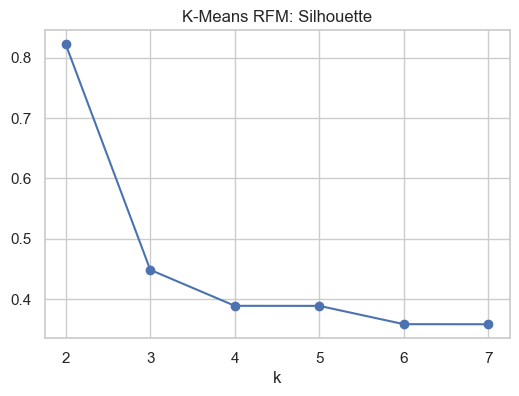

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  8.16it/s, max_LL=-1.36e+5, max_avg_LL=-16.9]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.79it/s, max_LL=-1.32e+5, max_avg_LL=-16.5]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.53s/it, max_LL=-1.3e+5, max_avg_LL=-16.2]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.54s/it, max_LL=-1.23e+5, max_avg_LL=-15.4]


,k,SABIC
0,2,271302.499022
1,3,263750.939218
2,4,261142.667429
3,5,259792.293081
4,6,246624.516681


In [30]:
RFM = df[["recency_days", "frequency", "monetary"]].copy()
X_rfm = StandardScaler().fit_transform(RFM)

sil_rfm = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_rfm)
    sil_rfm.append(silhouette_score(X_rfm, km.labels_))

plt.figure(figsize=(6, 4))
plt.plot(list(range(2, 8)), sil_rfm, marker="o")
plt.title("K-Means RFM: Silhouette")
plt.xlabel("k")
plt.show()

bic_rfm = []
for k in range(2, 7):
    m = StepMix(n_components=k, measurement="continuous", random_state=RANDOM_STATE, verbose=0)
    m.fit(RFM)
    bic_rfm.append(m.sabic(RFM))

pd.DataFrame({"k": range(2, 7), "SABIC": bic_rfm})


In [31]:
K_RFM_KMEANS = 3
K_RFM_LCA = 3

df["seg_rfm_kmeans"] = KMeans(n_clusters=K_RFM_KMEANS, random_state=RANDOM_STATE, n_init=10).fit_predict(X_rfm)

model_rfm_lca = StepMix(n_components=K_RFM_LCA, measurement="continuous", random_state=RANDOM_STATE, verbose=0)
model_rfm_lca.fit(RFM)
df["seg_rfm_lca"] = model_rfm_lca.predict(RFM)

df.groupby("seg_rfm_kmeans")[["recency_days", "frequency", "monetary", "promo_order_rate"]].mean().round(2)


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  3.24it/s, max_LL=-1.32e+5, max_avg_LL=-16.5]


,recency_days,frequency,monetary,promo_order_rate
seg_rfm_kmeans,,,,
0,51.33,33.23,3210.65,0.00
1,1299.37,2.18,255.70,0.36
2,317.00,3.93,482.09,0.33


## 8. Promociones y categoría de producto

Análisis alineado al objetivo del cliente: identificar categorías con mayor uso de descuentos y cruzar con segmentos.


In [32]:
orders["used_promo"] = (orders["discount_pct"] > 0).astype(int)

promo_cat = (
    orders.groupby("category")
    .agg(orders=("order_id", "count"), promo_rate=("used_promo", "mean"), avg_discount=("discount_pct", "mean"))
    .sort_values("promo_rate", ascending=False)
)
promo_cat.round(3)


,orders,promo_rate,avg_discount
category,,,
Jewelry & Accessories,973,0.380,6.285
Office Supplies,770,0.369,5.669
Health & Wellness,1219,0.364,5.935
Home & Kitchen,3068,0.359,5.776
Clothing & Apparel,3981,0.357,5.790
Books,1962,0.355,5.716
Automotive,768,0.353,5.404
Electronics,4526,0.351,5.521
Toys & Games,1518,0.348,5.642


In [33]:
# Categoría dominante por cliente (desde órdenes)
dom_cat = (
    orders.groupby(["customer_id", "category"])["order_id"].count()
    .reset_index(name="n")
    .sort_values(["customer_id", "n"], ascending=[True, False])
    .drop_duplicates("customer_id")
    .rename(columns={"category": "dominant_category"})
    [["customer_id", "dominant_category"]]
)
df = df.merge(dom_cat, on="customer_id", how="left")

seg_promo = (
    df.groupby(["seg_demo_kmeans", "dominant_category"], observed=True)
    .agg(n=("customer_id", "count"), promo_rate=("promo_order_rate", "mean"), spend=("monetary", "mean"))
    .reset_index()
    .sort_values(["seg_demo_kmeans", "promo_rate"], ascending=[True, False])
)
seg_promo.head(20)


,seg_demo_kmeans,dominant_category,n,promo_rate,spend
8,0,Jewelry & Accessories,14,0.387585,470.910714
10,0,Pet Supplies,12,0.333333,153.450000
5,0,Food & Grocery,36,0.324769,263.543611
3,0,Clothing & Apparel,238,0.315441,412.605168
2,0,Books,145,0.313432,329.352621
7,0,Home & Kitchen,99,0.301960,463.136465
4,0,Electronics,229,0.286307,592.935066
0,0,Automotive,75,0.279111,473.808400
9,0,Office Supplies,10,0.270000,332.705000
1,0,Beauty & Personal Care,133,0.263531,374.148346


## 9. Comparación de modelos y mercados meta

Criterios sugeridos para priorizar segmentos meta (completar con el criterio del grupo):
1. Alta `promo_order_rate` y `avg_discount_pct` (receptividad).
2. Alto `monetary` o `frequency` (valor).
3. Bajo `churn_flag` y membresía activa.
4. Tamaño del segmento (alcanzabilidad).


In [34]:
summary_meta = (
    df.groupby("seg_demo_kmeans")
    .agg(
        clientes=("customer_id", "count"),
        edad_prom=("age", "mean"),
        gasto_prom=("monetary", "mean"),
        promo_rate=("promo_order_rate", "mean"),
        desc_prom=("avg_discount_pct", "mean"),
        churn=("churn_flag", "mean"),
        newsletter=("newsletter", "mean"),
    )
    .round(3)
)
summary_meta["pct_base"] = (summary_meta["clientes"] / len(df) * 100).round(1)
summary_meta


,clientes,edad_prom,gasto_prom,promo_rate,desc_prom,churn,newsletter,pct_base
seg_demo_kmeans,,,,,,,,
0,1098,35.336,575.331,0.284,4.137,0.057,0.623,13.7
1,2371,35.793,372.925,0.692,12.342,0.112,0.606,29.6
2,4531,35.592,459.260,0.162,2.024,0.085,0.622,56.6


In [35]:
# Score simple para priorización (el grupo puede ponderar distinto)
z = df.groupby("seg_demo_kmeans").agg(
    promo=("promo_order_rate", "mean"),
    valor=("monetary", "mean"),
    freq=("frequency", "mean"),
).astype(float)

for c in z.columns:
    z[c] = (z[c] - z[c].mean()) / z[c].std(ddof=0)

z["score_meta"] = z["promo"] + z["valor"] - z.index.to_series().map(
    df.groupby("seg_demo_kmeans")["churn_flag"].mean()
).values

z.sort_values("score_meta", ascending=False)


,promo,valor,freq,score_meta
seg_demo_kmeans,,,,
0,-0.422725,1.280123,1.194440,0.800021
1,1.380113,-1.160603,-1.252952,0.107743
2,-0.957388,-0.119520,0.058512,-1.162320


## 10. Posicionamiento (borrador estructural)

Complete en la presentación / informe DOCX:

| Mercado meta (ID) | Propuesta de valor | Diferenciación vs. competencia | Táctica promocional por categoría |
|-------------------|-------------------|-------------------------------|-----------------------------------|
| Segmento _ | _ | _ | _ |

**Ejemplo de lógica (sin nombrar segmentos por IA):** segmentos con alta sensibilidad al descuento en *Clothing* o *Electronics* pueden recibir cupones dinámicos por categoría; segmentos RFM de alto valor pueden recibir beneficios de membresía en lugar de descuento profundo.


## 11. Conclusiones

1. Se limpiaron y enriquecieron 8.000 clientes con RFM y métricas promocionales desde 25.000 órdenes.
2. K-Means y StepMix entregan particiones comparables (ver matriz de cruce).
3. Las categorías con mayor tasa promocional deben guiar campañas de entrada.
4. **Acción pendiente del grupo:** nombrar segmentos, seleccionar mercados meta finales y redactar posicionamiento en PPT/DOCX.


In [36]:
# Export opcional para presentación
# df.to_csv("clientes_segmentados_grupo25.csv", index=False)
